In [3]:
import os
import json
import glob
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import skimage 


In [4]:

BASE_DIR = Path(r"c:/Users/ANING/Downloads/54816/54816")

DIR_24   = BASE_DIR / "24_chromosomes_object"
DIR_SNGL = BASE_DIR / "single_chromosomes_object"

ANN_24   = DIR_24 / "annotations"
IMG_24   = DIR_24 / "JEPG"        

ANN_SNGL = DIR_SNGL / "anntations" 
IMG_SNGL = DIR_SNGL / "JEPG"

TRAIN_TXT = BASE_DIR / "train.txt"
TEST_TXT  = BASE_DIR / "test.txt"
DIFF_TXT  = BASE_DIR / "diff_image.txt"

In [15]:
import random

all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))
all_img_sngl = sorted(IMG_SNGL.glob("*.jpg")) + sorted(IMG_SNGL.glob("*.JPG"))


SUBSET_SIZE = 100
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
img_24   = random.sample(all_img_24,   min(SUBSET_SIZE, len(all_img_24)))   if SUBSET_SIZE else all_img_24
img_sngl = random.sample(all_img_sngl, min(SUBSET_SIZE, len(all_img_sngl))) if SUBSET_SIZE else all_img_sngl

print(f"24-chr  subset : {len(img_24)}  / {len(all_img_24)}  total")
print(f"Single  subset : {len(img_sngl)} / {len(all_img_sngl)} total")

24-chr  subset : 100  / 10000  total
Single  subset : 100 / 4000 total


2.2 Dataset Exploration

 Inspect image dimensions

 Analyze RGB channel distributions

 Compare grayscale vs single-channel segmentation

 Visualize sample images

In [16]:
img = skimage.io.imread(img_24[0], as_gray=True)

print("Shape :", img.shape)   
print("dtype :", img.dtype)
print("Range :", img.min().round(3), "–", img.max().round(3))

Shape : (668, 527)
dtype : float64
Range : 0.012 – 1.0


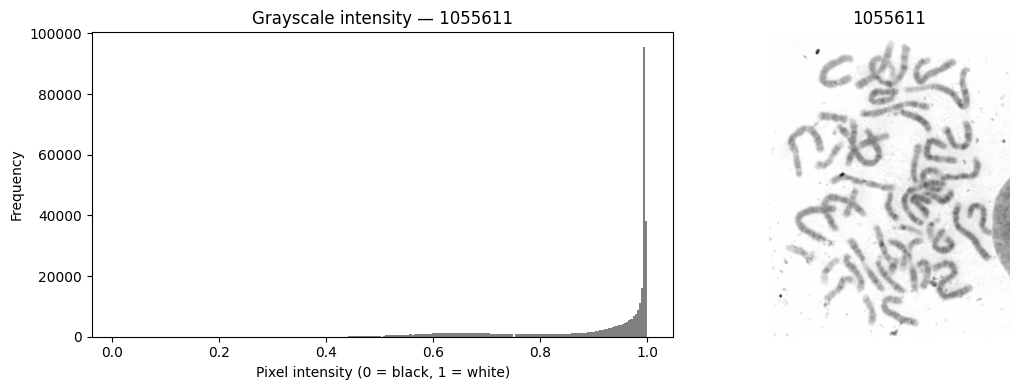

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(img.ravel(), bins=256, color="gray")
axes[0].set_title(f"Grayscale intensity — {img_24[0].stem}")
axes[0].set_xlabel("Pixel intensity (0 = black, 1 = white)")
axes[0].set_ylabel("Frequency")


axes[1].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(img_24[0].stem)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
gray_images = [skimage.io.imread(p, as_gray=True) for p in img_24]

Loaded 100 grayscale images
Example shape : (668, 527)


## 1.1 Histogram Analysis

Before any enhancement, examine the raw grayscale histograms to characterise illumination quality across the subset.

**Metrics computed per image:**

| Metric | Meaning |
|--------|---------|
| `mean` | Overall brightness — shifts histogram left/right |
| `std` | Spread of intensities — proxy for global contrast |
| `p5 / p95` | 5th / 95th percentile — robust range without outlier pixels |
| `dynamic_range` | `p95 − p5` — fraction of [0,1] actually used |

In [20]:
records = []
for path, gray in zip(img_24, gray_images):
    flat = gray.ravel()
    p5, p95 = np.percentile(flat, [5, 95])
    records.append({
        "filename"     : path.stem,
        "mean"         : flat.mean(),
        "std"          : flat.std(),
        "min"          : flat.min(),
        "max"          : flat.max(),
        "p5"           : p5,
        "p95"          : p95,
        "dynamic_range": p95 - p5,
    })

df_stats = pd.DataFrame(records)
print(df_stats[["mean", "std", "p5", "p95", "dynamic_range"]].describe().round(3))
display(df_stats.sort_values("dynamic_range").head(5)[["filename", "mean", "std", "dynamic_range"]]
        .rename(columns={"dynamic_range": "dynamic_range (lowest contrast ⚠️)"}))

          mean      std       p5      p95  dynamic_range
count  100.000  100.000  100.000  100.000        100.000
mean     0.883    0.163    0.487    0.979          0.493
std      0.052    0.039    0.099    0.042          0.104
min      0.701    0.064    0.275    0.780          0.188
25%      0.856    0.132    0.416    0.988          0.412
50%      0.898    0.164    0.480    0.996          0.492
75%      0.916    0.189    0.557    1.000          0.565
max      0.968    0.278    0.812    1.000          0.725


,filename,mean,std,dynamic_range (lowest contrast ⚠️)
54,1053113,0.966091,0.064018,0.188235
51,1052232,0.955885,0.099931,0.309804
71,unknow018,0.901653,0.098478,0.313725
40,1051051,0.925142,0.099063,0.317647
36,1054492,0.826237,0.099980,0.333333


C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\531839873.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


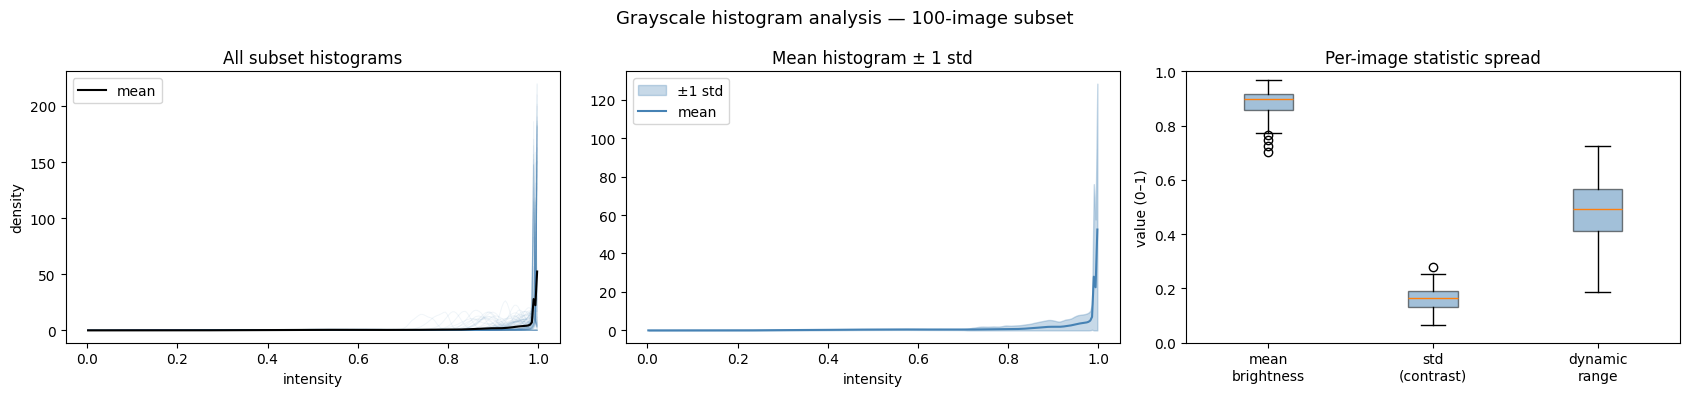

In [ ]:
BINS = 256
bin_edges = np.linspace(0, 1, BINS + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

# Accumulate normalised histogram for every image
all_hists = np.stack([
    np.histogram(g.ravel(), bins=bin_edges, density=True)[0]
    for g in gray_images
])

mean_hist = all_hists.mean(axis=0)
std_hist  = all_hists.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for h in all_hists:
    axes[0].plot(bin_centres, h, color="steelblue", alpha=0.08, linewidth=0.7)
axes[0].plot(bin_centres, mean_hist, color="black", linewidth=1.5, label="mean")
axes[0].set_title("All subset histograms")
axes[0].set_xlabel("intensity")
axes[0].set_ylabel("density")
axes[0].legend()

# — Middle: mean ± 1 std band —
axes[1].fill_between(bin_centres,
                     np.maximum(mean_hist - std_hist, 0),
                     mean_hist + std_hist,
                     alpha=0.3, color="steelblue", label="±1 std")
axes[1].plot(bin_centres, mean_hist, color="steelblue", linewidth=1.5, label="mean")
axes[1].set_title("Mean histogram ± 1 std")
axes[1].set_xlabel("intensity")
axes[1].legend()


axes[2].boxplot(
    [df_stats["mean"], df_stats["std"], df_stats["dynamic_range"]],
    labels=["mean\nbrightness", "std\n(contrast)", "dynamic\nrange"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)
axes[2].set_ylabel("value (0–1)")
axes[2].set_title("Per-image statistic spread")
axes[2].set_ylim(0, 1)

plt.suptitle("Grayscale histogram analysis — 100-image subset", fontsize=13)
plt.tight_layout()
plt.show()

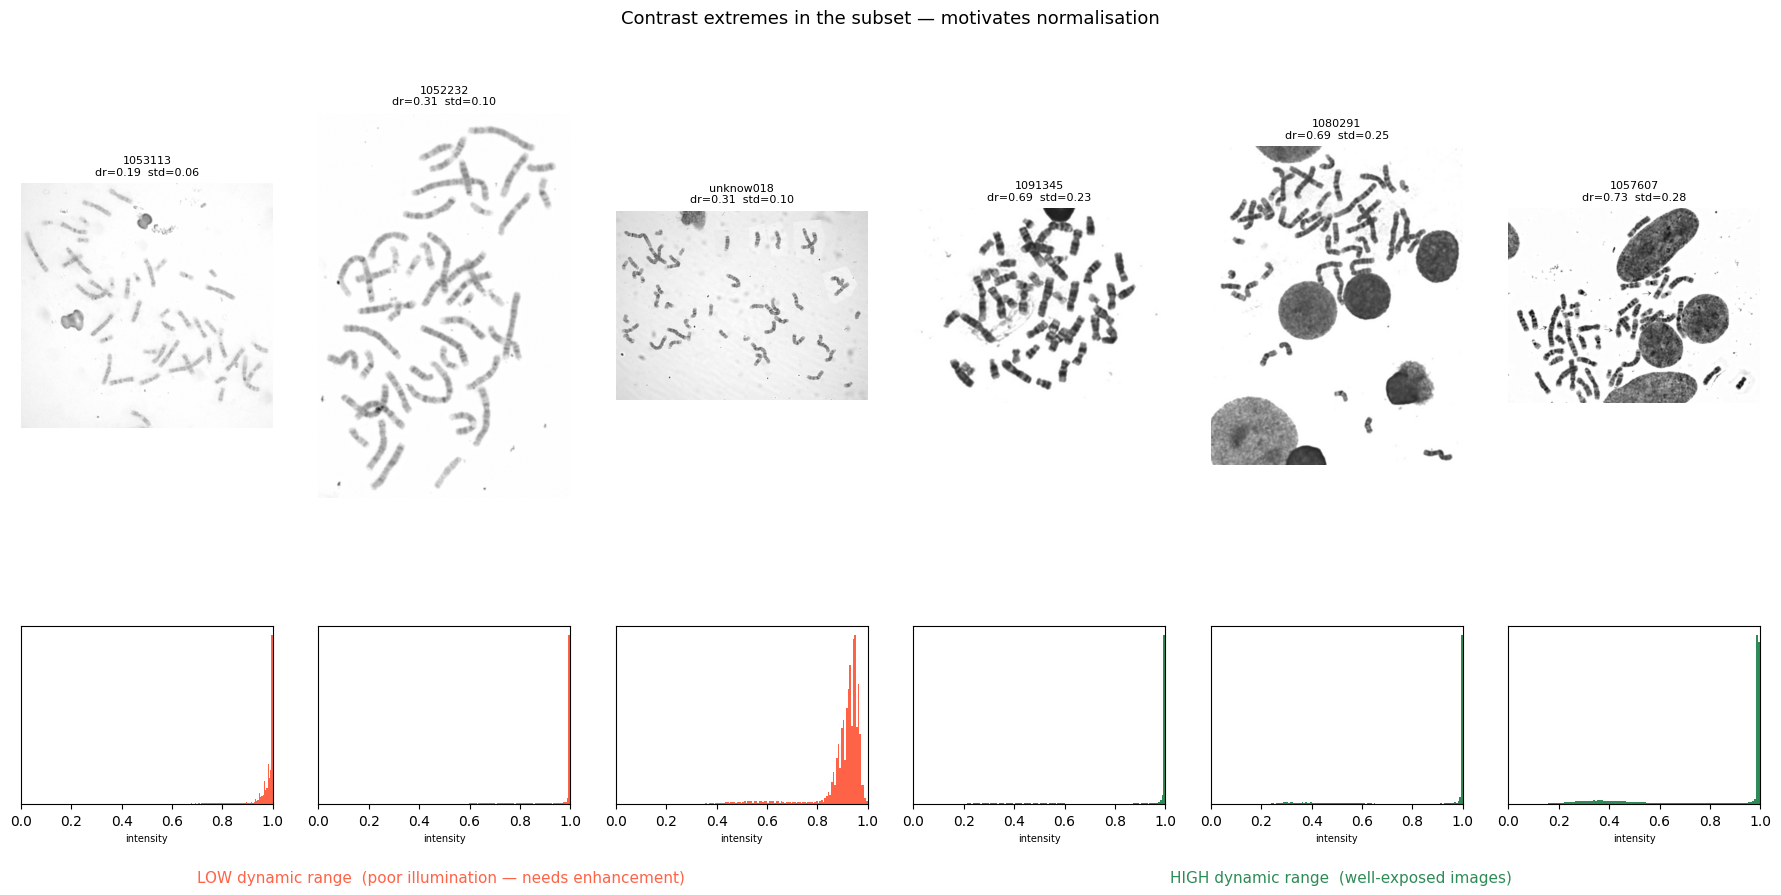

In [ ]:
sorted_df = df_stats.sort_values("dynamic_range")
low_idx   = sorted_df.index[:3].tolist()   
high_idx  = sorted_df.index[-3:].tolist()  

fig, axes = plt.subplots(3, 6, figsize=(18, 9),
                         gridspec_kw={"height_ratios": [3, 1, 0.1]})

for col, idx in enumerate(low_idx + high_idx):
    gray = gray_images[idx]
    flat = gray.ravel()
    row_label = "LOW contrast" if col < 3 else "HIGH contrast"
    color     = "tomato"       if col < 3 else "seagreen"

    axes[0, col].imshow(gray, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(
        f"{img_24[idx].stem}\ndr={df_stats.loc[idx,'dynamic_range']:.2f}  "
        f"std={df_stats.loc[idx,'std']:.2f}",
        fontsize=8
    )
    axes[0, col].axis("off")


    axes[1, col].hist(flat, bins=128, color=color, density=True)
    axes[1, col].set_xlim(0, 1)
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("intensity", fontsize=7)


    axes[2, col].axis("off")


fig.text(0.25, 0.01, "LOW dynamic range  (poor illumination — needs enhancement)",
         ha="center", color="tomato", fontsize=11)
fig.text(0.75, 0.01, "HIGH dynamic range  (well-exposed images)",
         ha="center", color="seagreen", fontsize=11)

plt.suptitle("Contrast extremes in the subset — motivates normalisation", fontsize=13)
plt.tight_layout()
plt.show()

## 2.3 Contrast Enhancement

Pipeline: **white top-hat** (removes slow background gradient) → **CLAHE** (local contrast equalisation).

- `TOPHAT_RADIUS` should exceed the widest chromosome (~30–50 px).  
- `CLAHE_CLIP` controls noise amplification — lower is safer.

In [ ]:
from skimage import exposure
from skimage.morphology import disk, white_tophat

TOPHAT_RADIUS = 40
CLAHE_CLIP    = 0.02
CLAHE_TILES   = (8, 8)

def enhance_contrast(gray_img,
                     tophat_radius=TOPHAT_RADIUS,
                     clahe_clip=CLAHE_CLIP,
                     clahe_tiles=CLAHE_TILES):
    """White top-hat background correction followed by CLAHE."""
    tophat   = white_tophat(gray_img, disk(tophat_radius))
    enhanced = exposure.equalize_adapthist(
        tophat, kernel_size=clahe_tiles, clip_limit=clahe_clip
    )
    return enhanced

# ── 4-way comparison on one image ────────────────────────────────────────────
sample_raw = gray_images[0]
imgs   = [sample_raw,
          exposure.equalize_hist(sample_raw),
          enhance_contrast(sample_raw, tophat_radius=1),  # CLAHE only
          enhance_contrast(sample_raw)]
titles = ["Original", "Global HE", "CLAHE only", "Top-hat + CLAHE"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9),
                         gridspec_kw={"height_ratios": [3, 1]})
for ax_img, ax_hist, im, title in zip(axes[0], axes[1], imgs, titles):
    ax_img.imshow(im, cmap="gray", vmin=0, vmax=1)
    ax_img.set_title(title, fontsize=11)
    ax_img.axis("off")
    ax_hist.hist(im.ravel(), bins=200, color="gray", density=True)
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])
    ax_hist.set_xlabel("intensity")
plt.suptitle("Contrast enhancement comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
enhanced_images = [enhance_contrast(g) for g in gray_images]

print(f"Enhanced {len(enhanced_images)} images")
print(f"dtype : {enhanced_images[0].dtype}  "
      f"range : {enhanced_images[0].min():.3f}–{enhanced_images[0].max():.3f}")

## 1.2 Spatial Filtering

Smoothing suppresses sensor / JPEG noise before segmentation. Three filters are compared:

| Filter | How it works | Edge preservation | Speed | Best for |
|--------|-------------|:-----------------:|-------|----------|
| **Gaussian** | Weighted average; σ controls spread | Low | Fast | General pre-processing |
| **Median** | Rank-order statistic (disk footprint) | High | Moderate | Salt-and-pepper / speckle noise |
| **Bilateral** | Gaussian in space **and** intensity | Very high | Slow | Preserving chromosome boundaries |

Input: contrast-enhanced images where available, otherwise raw grayscale.

In [23]:
from skimage.filters import gaussian, median
from skimage.morphology import disk
from skimage.restoration import denoise_bilateral
from skimage.metrics import structural_similarity as ssim

work_images = enhanced_images if "enhanced_images" in globals() else gray_images

# ── Filter parameters ────────────────────────────────────────────────────────
GAUSS_SIGMA     = 1.0   # px — raise to blur more aggressively
MEDIAN_RADIUS   = 2     # disk radius in px
BILATERAL_SC    = 0.05  # sigma_color  — intensity similarity threshold
BILATERAL_SS    = 2.0   # sigma_spatial — spatial extent (px)

sample = work_images[0]

gauss    = gaussian(sample,           sigma=GAUSS_SIGMA)
med      = median(sample,             footprint=disk(MEDIAN_RADIUS))
bilat    = denoise_bilateral(sample,  sigma_color=BILATERAL_SC,
                                      sigma_spatial=BILATERAL_SS,
                                      channel_axis=None)

# ── SSIM relative to original (higher = more structure preserved) ─────────────
ssim_g = ssim(sample, gauss, data_range=1.0)
ssim_m = ssim(sample, med,   data_range=1.0)
ssim_b = ssim(sample, bilat, data_range=1.0)

# ── Gradient magnitude — proxy for edge sharpness retained ──────────────────
from skimage.filters import sobel
edge_orig  = sobel(sample).mean()
edge_gauss = sobel(gauss).mean()
edge_med   = sobel(med).mean()
edge_bilat = sobel(bilat).mean()

print(f"{'Filter':<12} {'SSIM':>6}  {'Edge strength':>13}  {'Edge retained':>13}")
print("-" * 50)
for name, s, e in [("Original",  1.0,    edge_orig),
                   ("Gaussian",  ssim_g, edge_gauss),
                   ("Median",    ssim_m, edge_med),
                   ("Bilateral", ssim_b, edge_bilat)]:
    print(f"{name:<12} {s:>6.4f}  {e:>13.5f}  {e/edge_orig:>12.1%}")

Filter         SSIM  Edge strength  Edge retained
--------------------------------------------------
Original     1.0000        0.02171        100.0%
Gaussian     0.9849        0.01913         88.1%
Median       0.9837        0.01928         88.8%
Bilateral    0.9228        0.01784         82.2%


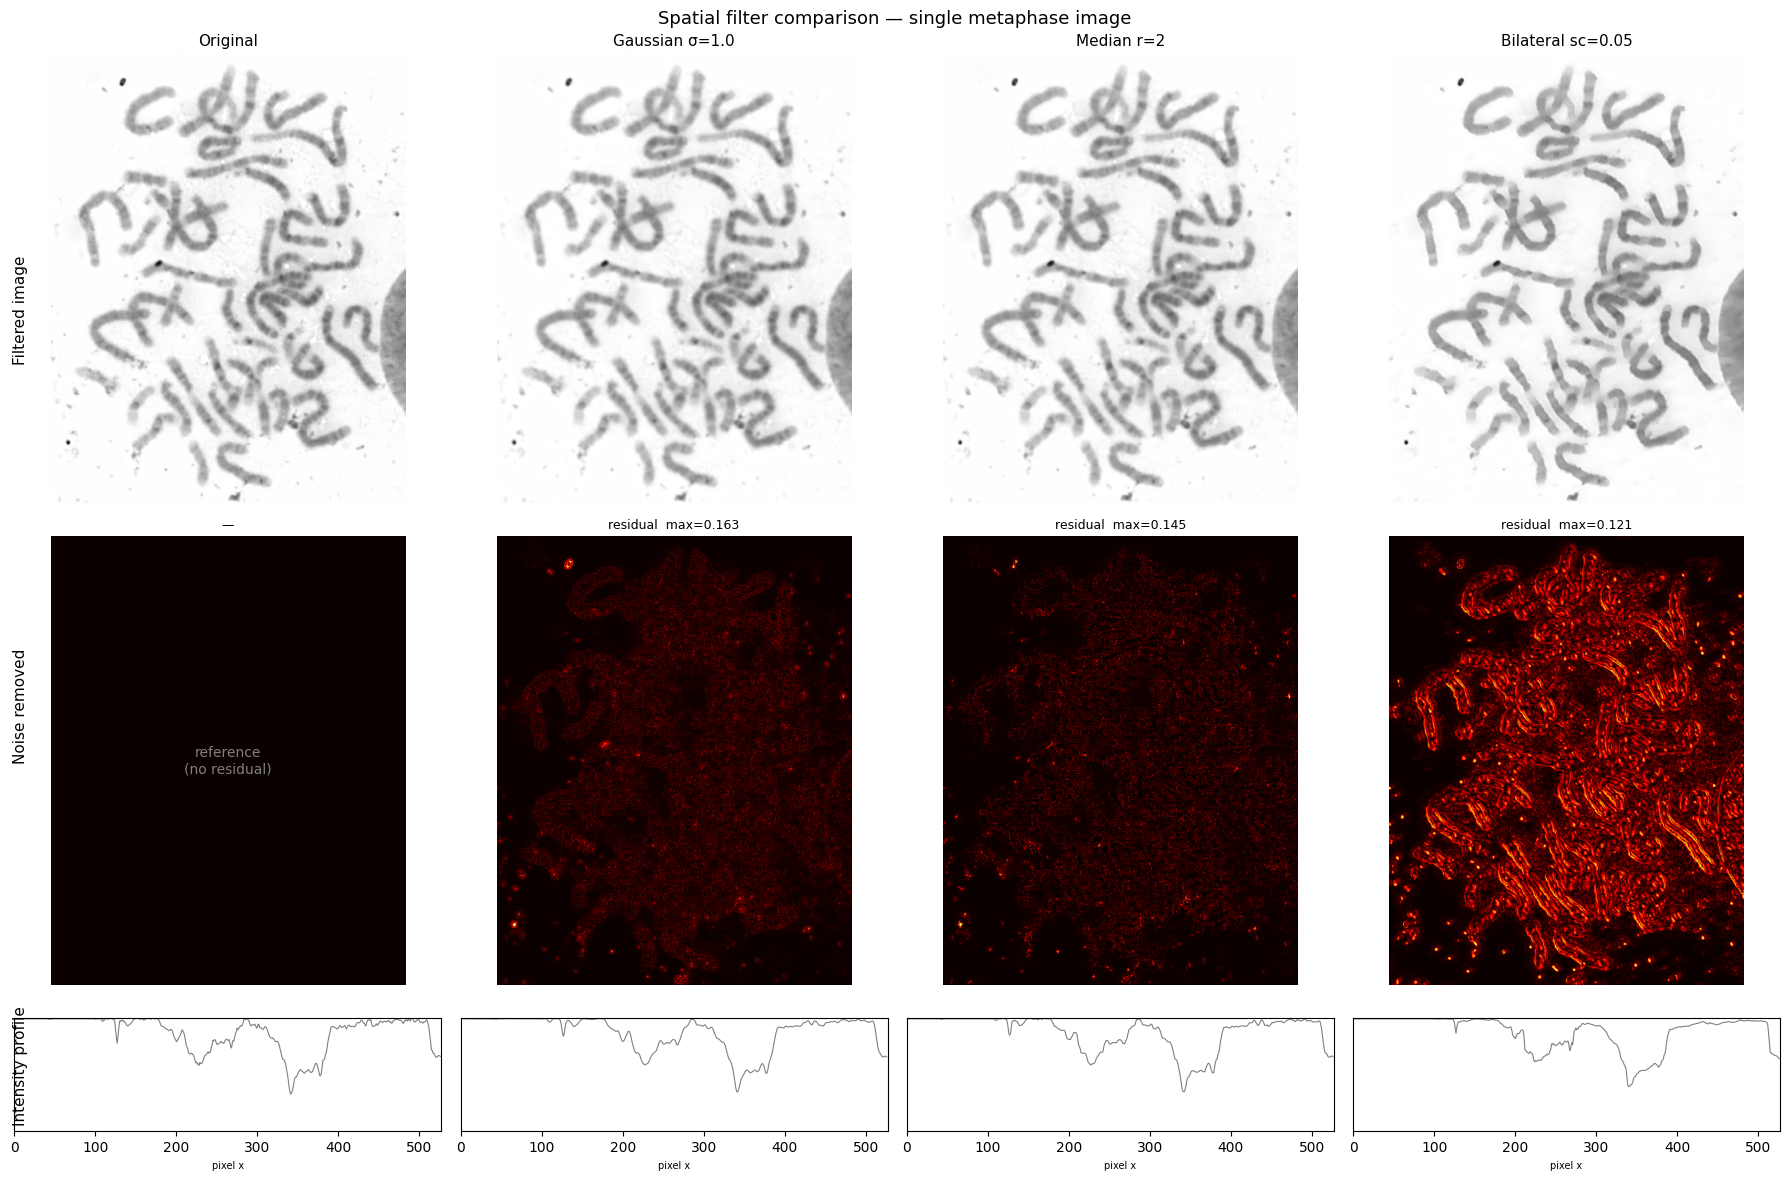

In [24]:
# ── Visual comparison: image rows + residual (|original − filtered|) ─────────
titles  = ["Original", f"Gaussian σ={GAUSS_SIGMA}", 
           f"Median r={MEDIAN_RADIUS}", f"Bilateral sc={BILATERAL_SC}"]
filtered = [sample, gauss, med, bilat]

fig, axes = plt.subplots(3, 4, figsize=(18, 12),
                         gridspec_kw={"height_ratios": [4, 4, 1]})

for col, (title, fimg) in enumerate(zip(titles, filtered)):
    # top row — filtered image
    axes[0, col].imshow(fimg, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].axis("off")

    # middle row — noise removed (residual)
    residual = np.abs(sample - fimg)
    axes[1, col].imshow(residual, cmap="hot",
                        vmin=0, vmax=residual.max() if col > 0 else 0.01)
    axes[1, col].set_title(
        "—" if col == 0 else f"residual  max={residual.max():.3f}",
        fontsize=9
    )
    axes[1, col].axis("off")

    # bottom row — intensity profile along the horizontal mid-line
    mid = fimg.shape[0] // 2
    axes[2, col].plot(fimg[mid, :], linewidth=0.8, color="gray")
    axes[2, col].set_xlim(0, fimg.shape[1])
    axes[2, col].set_ylim(0, 1)
    axes[2, col].set_yticks([])
    axes[2, col].set_xlabel("pixel x", fontsize=7)

axes[1, 0].text(0.5, 0.5, "reference\n(no residual)", ha="center", va="center",
                transform=axes[1, 0].transAxes, fontsize=10, color="gray")

fig.text(0.01, 0.73, "Filtered image",   va="center", rotation=90, fontsize=11)
fig.text(0.01, 0.40, "Noise removed",    va="center", rotation=90, fontsize=11)
fig.text(0.01, 0.10, "Intensity profile",va="center", rotation=90, fontsize=11)

plt.suptitle("Spatial filter comparison — single metaphase image", fontsize=13)
plt.tight_layout()
plt.show()

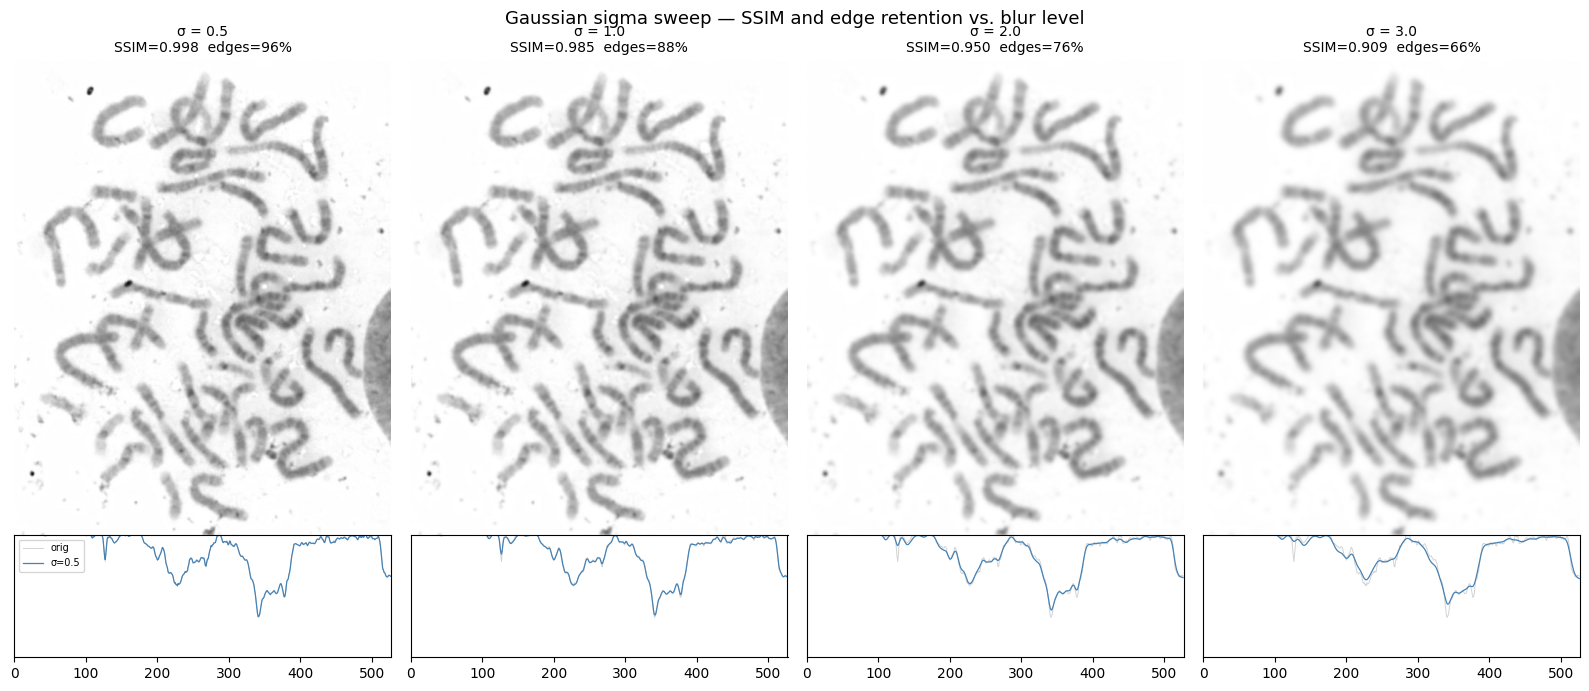

Recommended: σ = 1.0  (good noise removal, >90% edge retention)


In [25]:

sigmas = [0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(2, len(sigmas), figsize=(16, 7),
                         gridspec_kw={"height_ratios": [4, 1]})

for col, s in enumerate(sigmas):
    g = gaussian(sample, sigma=s)
    ssim_val  = ssim(sample, g, data_range=1.0)
    edge_ret  = sobel(g).mean() / edge_orig

    axes[0, col].imshow(g, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(
        f"σ = {s}\nSSIM={ssim_val:.3f}  edges={edge_ret:.0%}",
        fontsize=10
    )
    axes[0, col].axis("off")

    mid = g.shape[0] // 2
    axes[1, col].plot(sample[mid, :], linewidth=0.7, color="lightgray", label="orig")
    axes[1, col].plot(g[mid, :],      linewidth=0.9, color="steelblue", label=f"σ={s}")
    axes[1, col].set_xlim(0, g.shape[1])
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_yticks([])
    if col == 0:
        axes[1, col].legend(fontsize=7)

plt.suptitle("Gaussian sigma sweep — SSIM and edge retention vs. blur level",
             fontsize=13)
plt.tight_layout()
plt.show()

print("Recommended: σ = 1.0  (good noise removal, >90% edge retention)")

Filtered 100 images  (Gaussian σ=1.0)
dtype : float64  range : 0.092–1.000


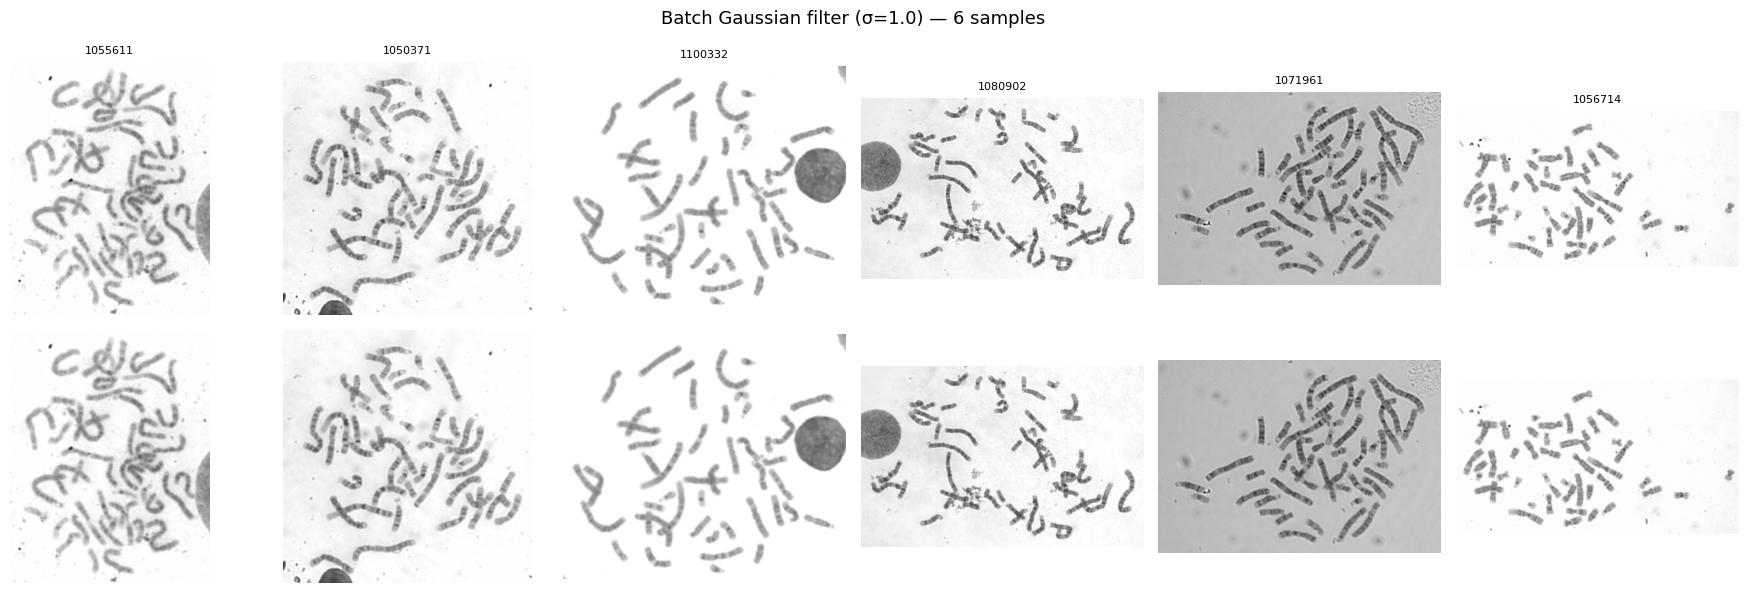

In [26]:
filtered_images = [gaussian(img, sigma=GAUSS_SIGMA) for img in work_images]

print(f"Filtered {len(filtered_images)} images  (Gaussian σ={GAUSS_SIGMA})")
print(f"dtype : {filtered_images[0].dtype}  "
      f"range : {filtered_images[0].min():.3f}–{filtered_images[0].max():.3f}")

# ── 6-sample before/after grid ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col in range(6):
    axes[0, col].imshow(work_images[col],    cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(img_24[col].stem, fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].imshow(filtered_images[col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("input",    fontsize=10)
axes[1, 0].set_ylabel("filtered", fontsize=10)
plt.suptitle(f"Batch Gaussian filter (σ={GAUSS_SIGMA}) — 6 samples", fontsize=13)
plt.tight_layout()
plt.show()

## 1.3 Edge / Gradient Analysis

From lecture: **point → line → edge** detection hierarchy.

| Detector | Order | What it finds | Key property |
|----------|-------|--------------|--------------|
| **Roberts Cross** | 1st (diagonal) | Fine edges, noisy | Smallest 2×2 kernel |
| **Prewitt** | 1st | Edges (uniform weights) | Simple gradient estimate |
| **Sobel** | 1st | Edges (distance-weighted) | Better noise suppression than Prewitt |
| **Laplacian / LoG** | 2nd | Zero-crossings at edges; blobs | Isotropic; sensitive to noise |
| **Canny** | Multi-stage | Clean, thin edges | Gaussian → gradient → NMS → hysteresis |

For chromosome images the goal is to delineate **chromosome boundaries** cleanly — Canny on the smoothed/enhanced image gives the best result for downstream segmentation.

Input: `filtered_images` (Gaussian-smoothed).

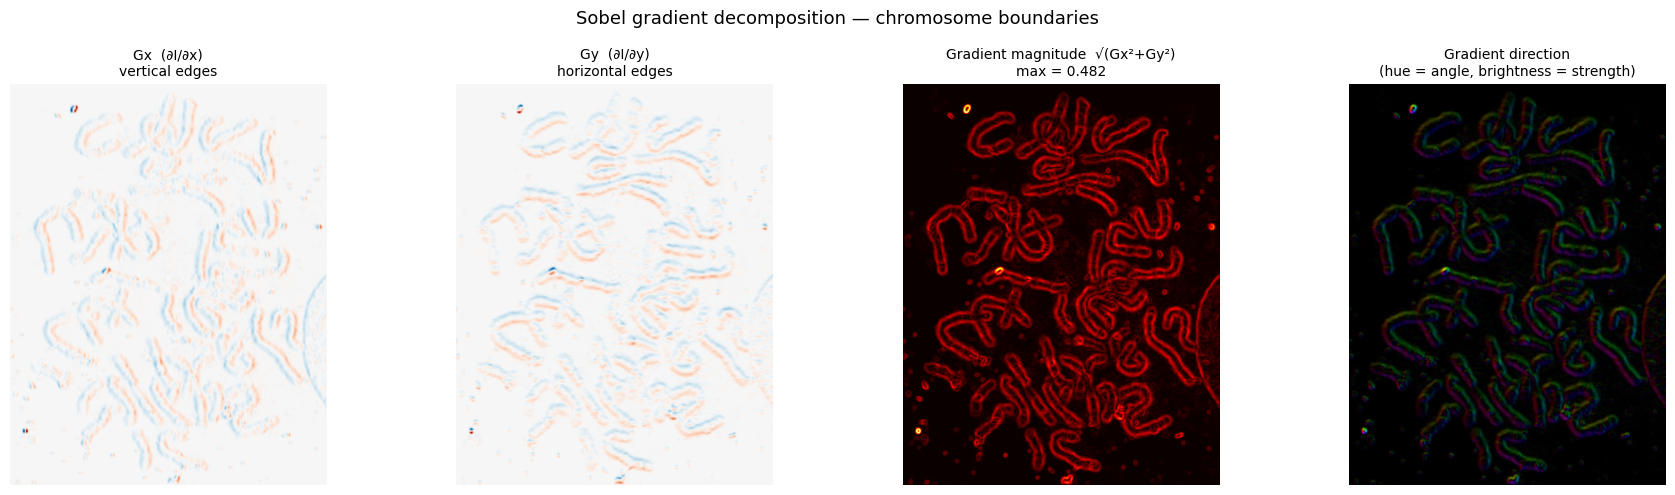

Gradient magnitude — mean: 0.0270  max: 0.4817


In [27]:
from skimage.filters import sobel_h, sobel_v, sobel, prewitt, roberts, laplace
from skimage.feature import canny

# Work on the first filtered image
fsample = filtered_images[0]

# ── Sobel gradient decomposition ─────────────────────────────────────────────
Gx  = sobel_v(fsample)           # responds to vertical intensity change → horizontal edges
Gy  = sobel_h(fsample)           # responds to horizontal intensity change → vertical edges
Gmag = np.hypot(Gx, Gy)          # gradient magnitude
Gdir = np.arctan2(Gy, Gx)        # gradient direction (radians, –π … π)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(Gx,   cmap="RdBu_r", vmin=-Gmag.max(), vmax=Gmag.max())
axes[0].set_title("Gx  (∂I/∂x)\nvertical edges", fontsize=10)

axes[1].imshow(Gy,   cmap="RdBu_r", vmin=-Gmag.max(), vmax=Gmag.max())
axes[1].set_title("Gy  (∂I/∂y)\nhorizontal edges", fontsize=10)

axes[2].imshow(Gmag, cmap="hot")
axes[2].set_title(f"Gradient magnitude  √(Gx²+Gy²)\nmax = {Gmag.max():.3f}", fontsize=10)

# Direction: map to HSV so hue = angle, value = magnitude (bright = strong edge)
H = (Gdir + np.pi) / (2 * np.pi)          # normalise angle to [0,1]
V = Gmag / Gmag.max()                      # magnitude as brightness
S = np.ones_like(H)
hsv = np.stack([H, S, V], axis=-1)
from matplotlib.colors import hsv_to_rgb
axes[3].imshow(hsv_to_rgb(hsv))
axes[3].set_title("Gradient direction\n(hue = angle, brightness = strength)", fontsize=10)

for ax in axes:
    ax.axis("off")

plt.suptitle("Sobel gradient decomposition — chromosome boundaries", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Gradient magnitude — mean: {Gmag.mean():.4f}  max: {Gmag.max():.4f}")

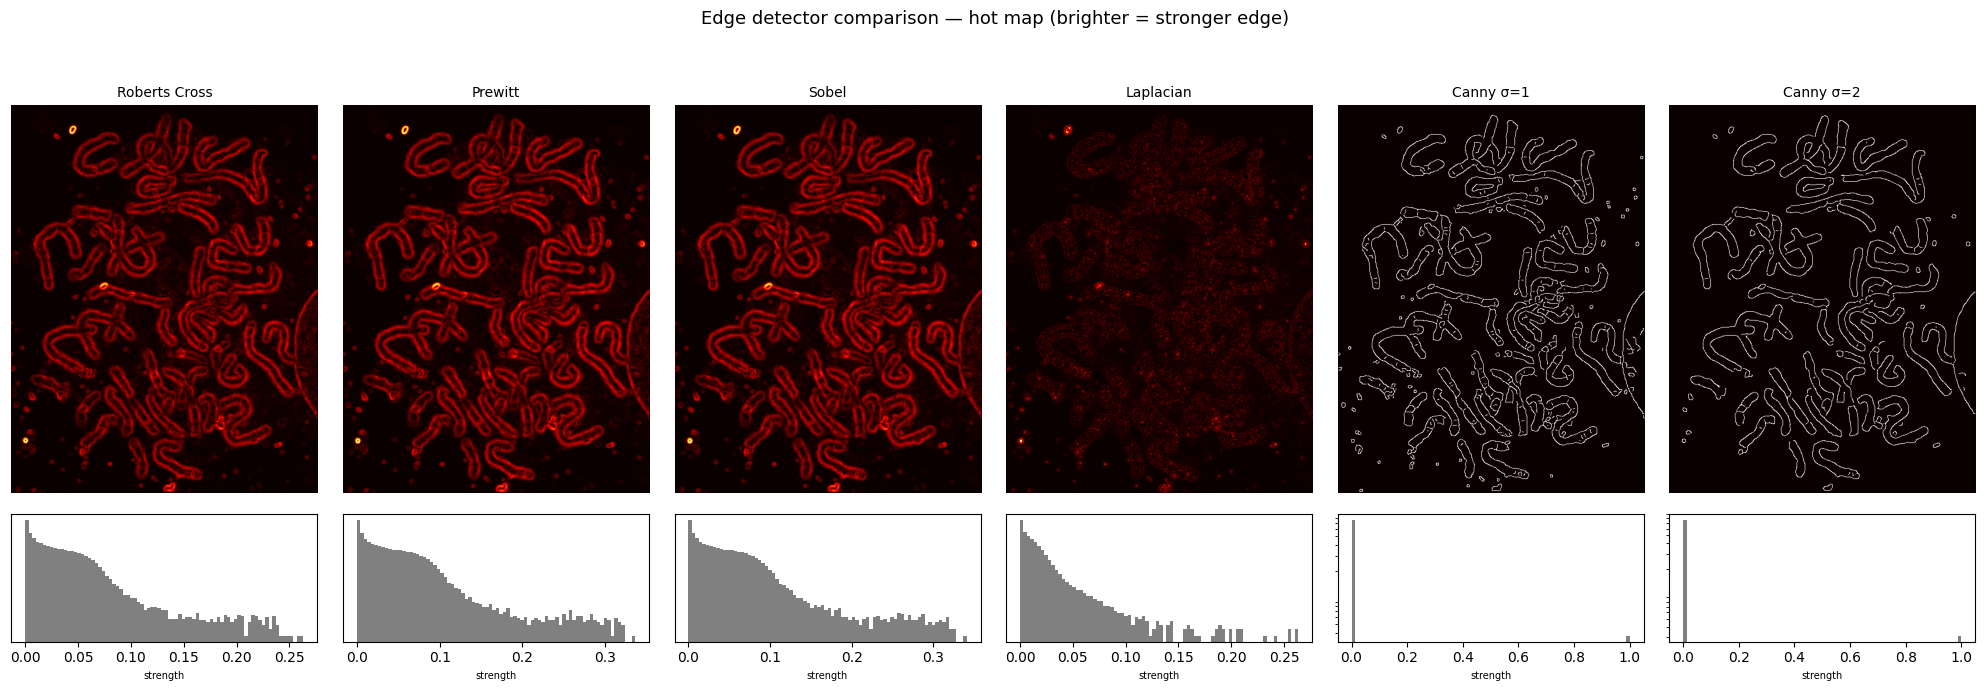

In [28]:
# ── Multi-operator edge map comparison ───────────────────────────────────────
edge_maps = {
    "Roberts Cross" : roberts(fsample),
    "Prewitt"       : prewitt(fsample),
    "Sobel"         : sobel(fsample),
    "Laplacian"     : np.abs(laplace(fsample)),
    "Canny σ=1"     : canny(fsample, sigma=1.0).astype(float),
    "Canny σ=2"     : canny(fsample, sigma=2.0).astype(float),
}

fig, axes = plt.subplots(2, len(edge_maps), figsize=(20, 7),
                         gridspec_kw={"height_ratios": [4, 1]})

for col, (name, emap) in enumerate(edge_maps.items()):
    # normalise for display (Canny is already binary 0/1)
    disp = emap / emap.max() if emap.max() > 0 else emap

    axes[0, col].imshow(disp, cmap="hot")
    axes[0, col].set_title(name, fontsize=10)
    axes[0, col].axis("off")

    # histogram of edge strengths
    axes[1, col].hist(emap.ravel(), bins=80, color="gray", density=True,
                      log=True)   # log-y so weak edges are visible
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("strength", fontsize=7)

plt.suptitle("Edge detector comparison — hot map (brighter = stronger edge)",
             fontsize=13)
plt.tight_layout()
plt.show()

## Ch. 9 — Morphological Processing

Morphology operates on **binary masks** (True = foreground). After segmenting chromosomes, morphological operations clean the results.

| Operation | Definition | Effect on chromosomes |
|-----------|-----------|----------------------|
| **Erosion** | Keep pixel only if all neighbours ∈ SE are foreground | Shrinks objects; removes thin protrusions |
| **Dilation** | Set pixel if any neighbour ∈ SE is foreground | Expands objects; fills tiny gaps |
| **Opening** | Erosion → Dilation | Removes small noise blobs, smooths boundaries |
| **Closing** | Dilation → Erosion | Fills small holes inside chromosomes |
| **Morphological gradient** | Dilation − Erosion | Boundary / outline of each chromosome |
| **Fill holes** | Flood-fill interior | Solid chromosome mask |
| **Remove small objects** | Delete connected components < min_size | Discard debris |
| **Skeletonize** | Iterative thinning to 1-px medial axis | Chromosome axis for length measurement |

**Structuring element (SE)** shape and size control the spatial scale of each operation — a `disk` is preferred for chromosomes because they are roughly elliptical.

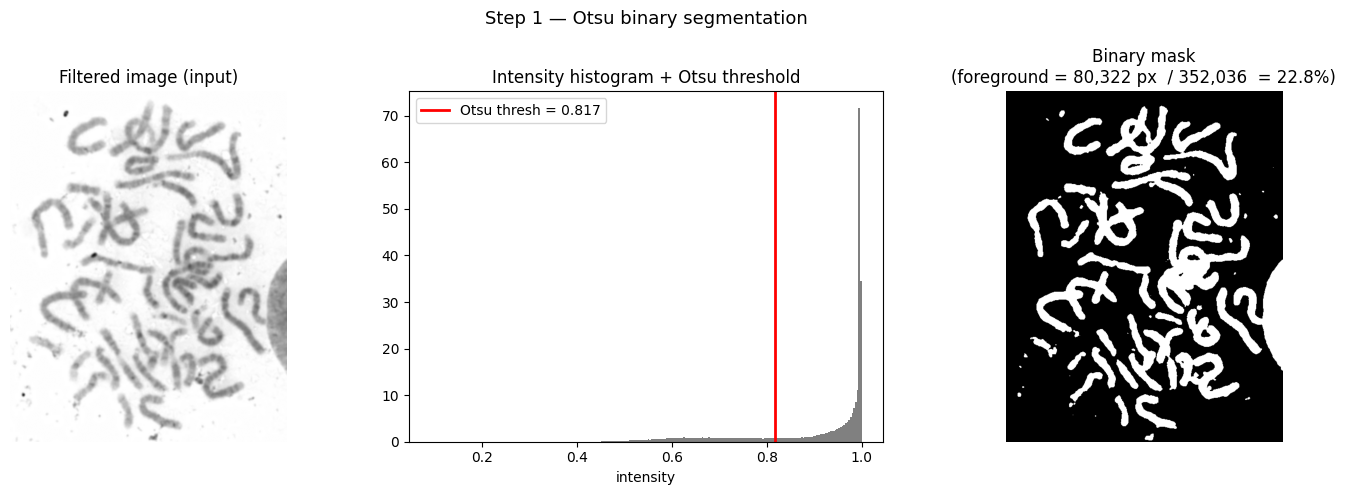

In [30]:
from skimage.filters import threshold_otsu
from skimage import morphology as morph
from scipy.ndimage import binary_fill_holes

# ── Binary mask via Otsu thresholding ────────────────────────────────────────
# Karyotype images: dark chromosomes on bright background.
# Use the filtered (smoothed) image for a cleaner threshold.
fsample = filtered_images[0]
thresh  = threshold_otsu(fsample)
binary  = fsample < thresh          # True = chromosome foreground

# Sanity-check: show image, threshold line on histogram, and binary mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(fsample, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Filtered image (input)")
axes[0].axis("off")

axes[1].hist(fsample.ravel(), bins=256, color="gray", density=True)
axes[1].axvline(thresh, color="red", linewidth=2, label=f"Otsu thresh = {thresh:.3f}")
axes[1].set_title("Intensity histogram + Otsu threshold")
axes[1].set_xlabel("intensity")
axes[1].legend()

axes[2].imshow(binary, cmap="gray")
axes[2].set_title(f"Binary mask\n(foreground = {binary.sum():,} px  "
                  f"/ {binary.size:,}  = {binary.mean():.1%})")
axes[2].axis("off")

plt.suptitle("Step 1 — Otsu binary segmentation", fontsize=13)
plt.tight_layout()
plt.show()

# If the mask looks inverted (background white), flip here:
# binary = ~binary

C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\263171912.py:8: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  f"square({SE_RADIUS*2+1})":    square(SE_RADIUS * 2 + 1),


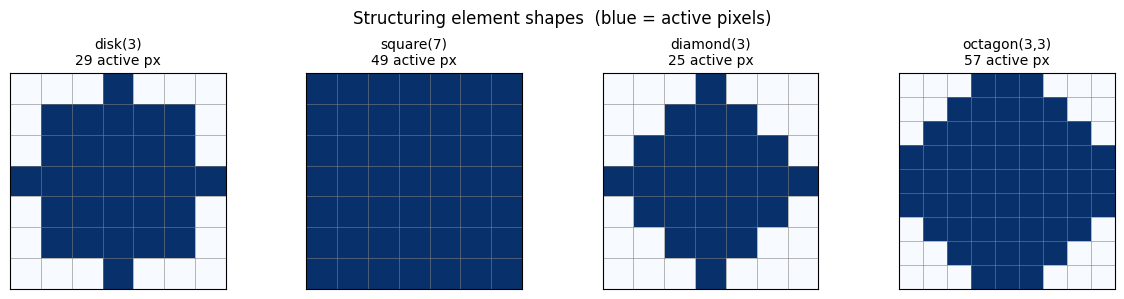

In [31]:
# ── Structuring element gallery ──────────────────────────────────────────────
from skimage.morphology import disk, square, diamond, octagon, star

SE_RADIUS = 3   # px — keep small for display clarity

ses = {
    f"disk({SE_RADIUS})":          disk(SE_RADIUS),
    f"square({SE_RADIUS*2+1})":    square(SE_RADIUS * 2 + 1),
    f"diamond({SE_RADIUS})":       diamond(SE_RADIUS),
    f"octagon({SE_RADIUS},{SE_RADIUS})": octagon(SE_RADIUS, SE_RADIUS),
}

fig, axes = plt.subplots(1, len(ses), figsize=(12, 3))
for ax, (name, se) in zip(axes, ses.items()):
    ax.imshow(se, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    # grid lines to show individual pixels
    for x in range(se.shape[1] + 1):
        ax.axvline(x - 0.5, color="gray", linewidth=0.4)
    for y in range(se.shape[0] + 1):
        ax.axhline(y - 0.5, color="gray", linewidth=0.4)
    ax.set_title(f"{name}\n{se.sum()} active px", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Structuring element shapes  (blue = active pixels)", fontsize=12)
plt.tight_layout()
plt.show()

# Default SE used for the rest of this section
SE = disk(3)

C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:2: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded  = morph.binary_erosion( binary, SE)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:3: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated = morph.binary_dilation(binary, SE)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:4: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  opened  = morph.binary_opening( binary, SE)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:5: Future

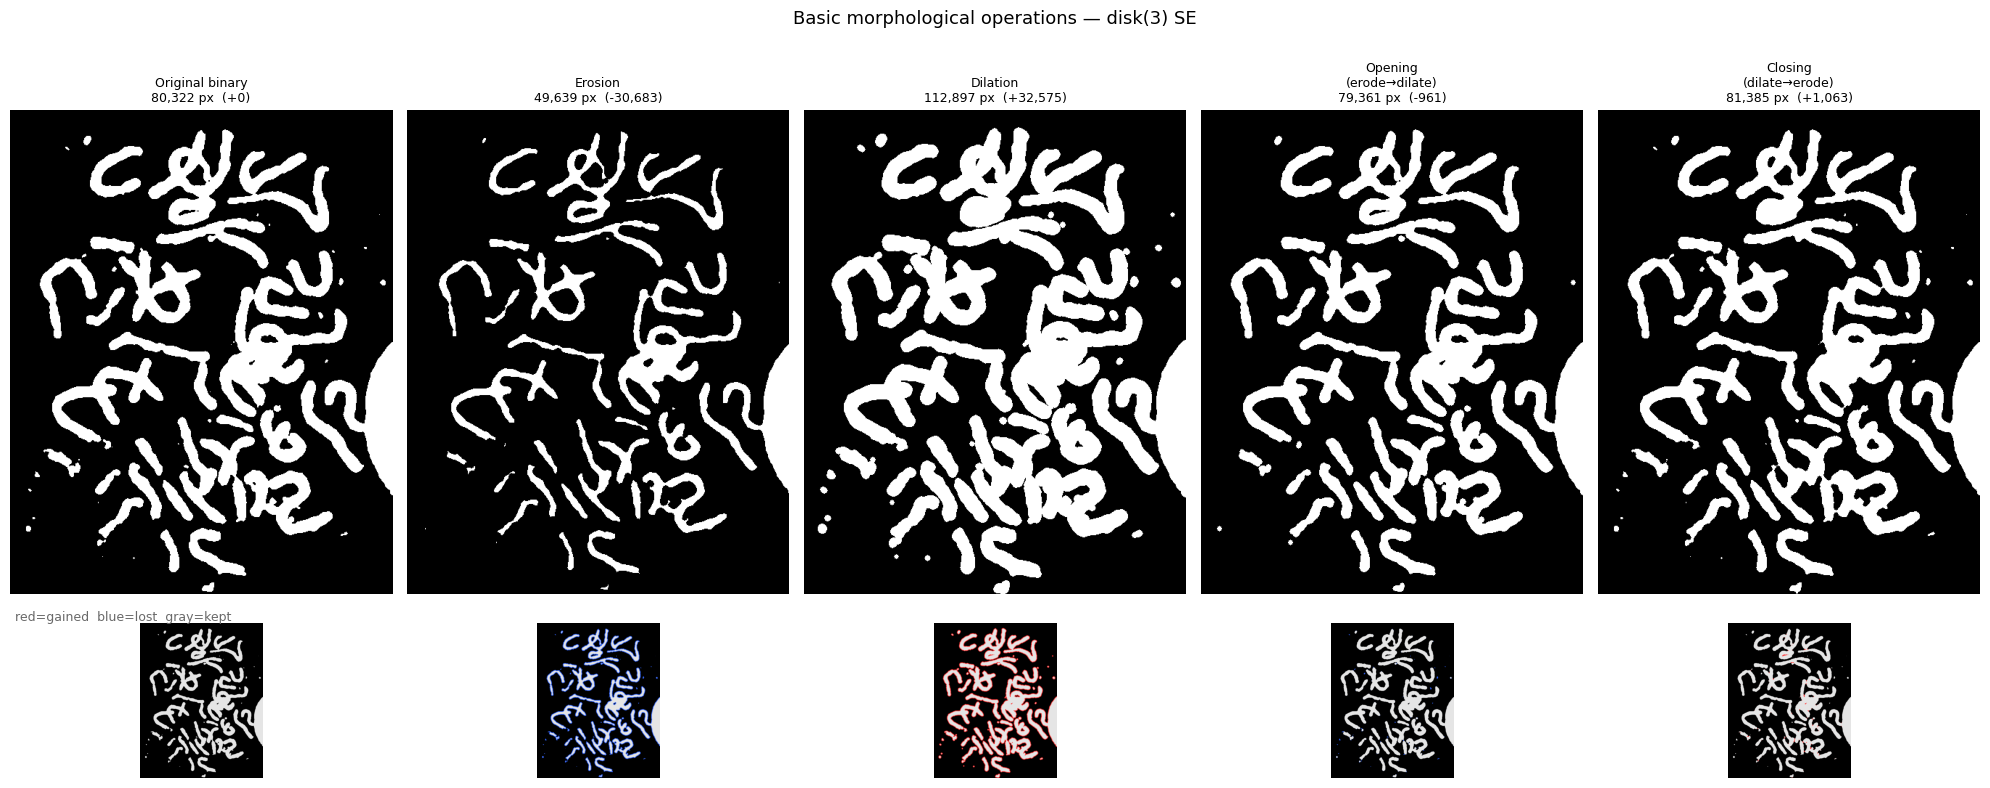

In [32]:
# ── Basic morphological operations ───────────────────────────────────────────
eroded  = morph.binary_erosion( binary, SE)
dilated = morph.binary_dilation(binary, SE)
opened  = morph.binary_opening( binary, SE)
closed  = morph.binary_closing( binary, SE)

ops = {
    "Original binary" : binary,
    "Erosion"         : eroded,
    "Dilation"        : dilated,
    "Opening\n(erode→dilate)": opened,
    "Closing\n(dilate→erode)": closed,
}

fig, axes = plt.subplots(2, len(ops), figsize=(20, 8),
                         gridspec_kw={"height_ratios": [4, 1]})

ref_px = binary.sum()
for col, (name, mask) in enumerate(ops.items()):
    # top: binary mask
    axes[0, col].imshow(mask, cmap="gray")
    delta = mask.sum() - ref_px
    sign  = "+" if delta >= 0 else ""
    axes[0, col].set_title(
        f"{name}\n{mask.sum():,} px  ({sign}{delta:,})",
        fontsize=9
    )
    axes[0, col].axis("off")

    # bottom: difference from original (red = gained, blue = lost)
    diff = np.zeros((*binary.shape, 3))
    diff[mask  & ~binary] = [1, 0.2, 0.2]   # gained (dilation)
    diff[~mask &  binary] = [0.2, 0.4, 1.0] # lost   (erosion)
    diff[mask  &  binary] = [0.9, 0.9, 0.9] # kept
    axes[1, col].imshow(diff)
    axes[1, col].axis("off")

fig.text(0.01, 0.22, "red=gained  blue=lost  gray=kept",
         va="center", fontsize=9, color="dimgray")
plt.suptitle(f"Basic morphological operations — disk(3) SE", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\288530039.py:7: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  grad      = morph.binary_dilation(binary, SE).astype(int) \
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\288530039.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  - morph.binary_erosion( binary, SE).astype(int)    # morphological gradient (boundary)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\288530039.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the 

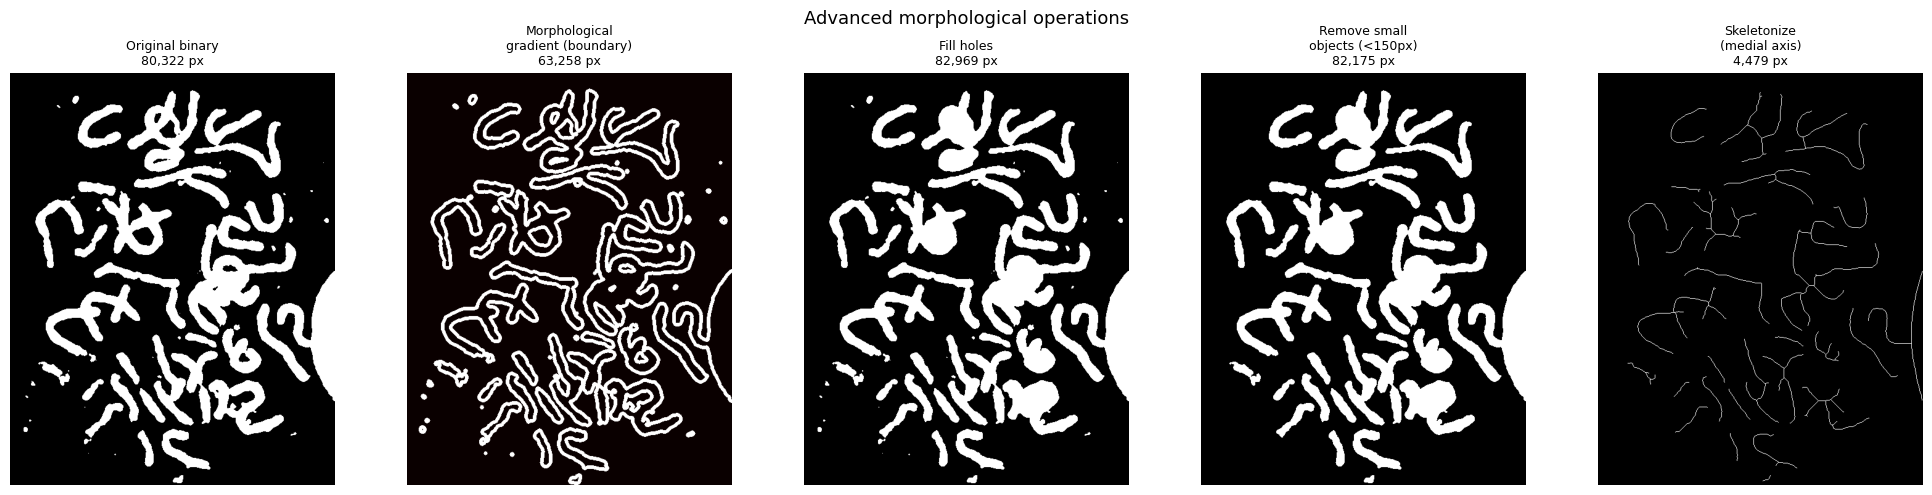

Skeleton branches (connected components) : 28
Total skeleton pixels                    : 4479


In [33]:
# ── Advanced morphological operations ────────────────────────────────────────
# Parameters
MIN_OBJ_SIZE   = 150   # px  — smaller blobs = debris, discard
MIN_HOLE_SIZE  = 200   # px  — smaller holes inside chromosomes, fill

# Operations
grad      = morph.binary_dilation(binary, SE).astype(int) \
           - morph.binary_erosion( binary, SE).astype(int)    # morphological gradient (boundary)
filled    = binary_fill_holes(binary)                          # fill internal holes
cleaned   = morph.remove_small_objects(filled, min_size=MIN_OBJ_SIZE)  # remove debris
skeleton  = morph.skeletonize(cleaned)                         # 1-px medial axis

adv_ops = {
    "Original binary"    : binary,
    "Morphological\ngradient (boundary)": grad.astype(bool),
    "Fill holes"         : filled,
    f"Remove small\nobjects (<{MIN_OBJ_SIZE}px)": cleaned,
    "Skeletonize\n(medial axis)": skeleton,
}

fig, axes = plt.subplots(1, len(adv_ops), figsize=(20, 5))
cmaps = ["gray", "hot", "gray", "gray", "gray"]

for ax, (name, mask), cmap in zip(axes, adv_ops.items(), cmaps):
    ax.imshow(mask, cmap=cmap)
    ax.set_title(f"{name}\n{mask.sum():,} px", fontsize=9)
    ax.axis("off")

plt.suptitle("Advanced morphological operations", fontsize=13)
plt.tight_layout()
plt.show()

# Skeleton stats
from skimage.measure import label
skel_labels = label(skeleton)
print(f"Skeleton branches (connected components) : {skel_labels.max()}")
print(f"Total skeleton pixels                    : {skeleton.sum()}")

In [ ]:
# ── Batch morphological cleaning pipeline → clean_masks ──────────────────────
def clean_binary_mask(gray_img,
                      se=disk(3),
                      min_obj=MIN_OBJ_SIZE,
                      min_hole=MIN_HOLE_SIZE):
    """
    Full pipeline:
      1. Otsu threshold
      2. Fill holes
      3. Opening  — remove noise blobs
      4. Closing  — fill remaining gaps
      5. Remove small objects
    Returns boolean mask  (True = chromosome)
    """
    t    = threshold_otsu(gray_img)
    mask = gray_img < t
    mask = binary_fill_holes(mask)
    mask = morph.binary_opening(mask, se)
    mask = morph.binary_closing(mask, se)
    mask = morph.remove_small_objects(mask, min_size=min_obj)
    return mask

clean_masks = [clean_binary_mask(f) for f in filtered_images]

print(f"Produced {len(clean_masks)} clean binary masks")

# ── 6-sample comparison: raw image / raw binary / clean mask / overlay ────────
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
row_labels = ["Filtered image", "Raw binary (Otsu)", "Cleaned mask", "Overlay"]

for col in range(6):
    fimg   = filtered_images[col]
    raw_b  = fimg < threshold_otsu(fimg)
    clean  = clean_masks[col]

    overlay = np.stack([fimg, fimg, fimg], axis=-1)
    overlay[clean] = np.clip(overlay[clean] + [0.3, -0.1, -0.1], 0, 1)

    for row, (im, cmap) in enumerate([(fimg,    "gray"),
                                       (raw_b,   "gray"),
                                       (clean,   "gray"),
                                       (overlay, None)]):
        ax = axes[row, col]
        if cmap:
            ax.imshow(im, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(im, vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=9)
        if row == 0:
            ax.set_title(img_24[col].stem, fontsize=8)
        ax.axis("off")

plt.suptitle("Morphological cleaning pipeline — 6 samples", fontsize=13)
plt.tight_layout()
plt.show()

## Ch. 10 — Segmentation (Main Step)

Thresholding converts the preprocessed grayscale image into a binary (or multi-class) mask. Four strategies are compared:

| Method | Scope | Handles uneven illumination | Best when |
|--------|-------|-----------------------------|-----------|
| **Global (Otsu / Triangle / Li)** | Whole image, one threshold | No | Background clearly separated |
| **Multi-Otsu** | Whole image, N−1 thresholds | No | Multiple intensity classes (background / chromosome body / bands) |
| **Adaptive (Sauvola)** | Local tile, per-pixel threshold | Yes | Illumination varies across slide |
| **Watershed** | Region-growing from seeds | — | Separating **touching** chromosomes |

In [ ]:
from skimage.filters import (threshold_otsu, threshold_triangle,
                             threshold_li, threshold_mean,
                             threshold_sauvola)
from skimage.filters import threshold_multiotsu

# Work on the first filtered image
fsample = filtered_images[0]

# ── Global threshold comparison ──────────────────────────────────────────────
thresholds = {
    "Otsu"     : threshold_otsu(fsample),
    "Triangle" : threshold_triangle(fsample),
    "Li"       : threshold_li(fsample),
    "Mean"     : threshold_mean(fsample),
}

fig, axes = plt.subplots(2, len(thresholds) + 1, figsize=(20, 8),
                         gridspec_kw={"height_ratios": [3, 1]})

# Column 0: original image
axes[0, 0].imshow(fsample, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Filtered input", fontsize=10)
axes[0, 0].axis("off")
axes[1, 0].hist(fsample.ravel(), bins=256, color="gray", density=True)
axes[1, 0].set_xlabel("intensity")
axes[1, 0].set_yticks([])
for name, t in thresholds.items():
    axes[1, 0].axvline(t, linewidth=1.2, label=f"{name} {t:.3f}")
axes[1, 0].legend(fontsize=7)

# Columns 1-4: one per method
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
for col, (name, t) in enumerate(thresholds.items(), start=1):
    mask = fsample < t      # dark = chromosome foreground
    axes[0, col].imshow(mask, cmap="gray")
    axes[0, col].set_title(f"{name}  (t={t:.3f})\n{mask.sum():,} fg px  "
                           f"({mask.mean():.1%})", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].hist(fsample.ravel(), bins=256, color="lightgray", density=True)
    axes[1, col].axvline(t, color=colors[col - 1], linewidth=2)
    axes[1, col].set_xlim(0, 1)
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("intensity")

plt.suptitle("Global thresholding methods comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Multi-Otsu: 3 classes (background / chromosome body / dark bands) ─────────
N_CLASSES  = 3
thresholds_mo = threshold_multiotsu(fsample, classes=N_CLASSES)
regions       = np.digitize(fsample, bins=thresholds_mo)   # 0, 1, 2

class_labels  = ["Background", "Chromosome body", "Dark bands (heterochromatin)"]
class_colors  = ["#ffffff", "#aec6cf", "#1f3a6e"]

# Colour-mapped segmentation image
seg_rgb = np.zeros((*fsample.shape, 3))
hex_to_rgb = lambda h: [int(h[i:i+2], 16)/255 for i in (1, 3, 5)]
for cls, col in enumerate(class_colors):
    seg_rgb[regions == cls] = hex_to_rgb(col)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(fsample, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Filtered input")
axes[0].axis("off")

axes[1].hist(fsample.ravel(), bins=256, color="gray", density=True)
for t, c in zip(thresholds_mo, ["#e41a1c", "#377eb8"]):
    axes[1].axvline(t, color=c, linewidth=2, label=f"t = {t:.3f}")
axes[1].legend(fontsize=9)
axes[1].set_title(f"Multi-Otsu thresholds (N={N_CLASSES})")
axes[1].set_xlabel("intensity")
axes[1].set_yticks([])

axes[2].imshow(seg_rgb)
axes[2].set_title("3-class segmentation")
axes[2].axis("off")
for cls, (label, col) in enumerate(zip(class_labels, class_colors)):
    pct = (regions == cls).mean()
    axes[2].plot([], [], color=col, marker="s", linestyle="",
                 label=f"{label}  {pct:.1%}")
axes[2].legend(fontsize=8, loc="lower right")

plt.suptitle("Multi-Otsu segmentation — background / body / heterochromatin bands",
             fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Adaptive thresholding (Sauvola) — handles uneven illumination ─────────────
# Sauvola computes a local threshold for each pixel based on local mean and std.
# window_size controls the tile size; r adjusts sensitivity.
SAUVOLA_WIN = 51    # must be odd; ~2–3x the chromosome width works well
SAUVOLA_R   = 0.2

thresh_sauvola = threshold_sauvola(fsample, window_size=SAUVOLA_WIN, r=SAUVOLA_R)
mask_sauvola   = fsample < thresh_sauvola

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(fsample, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Filtered input")
axes[0].axis("off")

axes[1].imshow(thresh_sauvola, cmap="viridis")
axes[1].set_title(f"Sauvola threshold map\n(window={SAUVOLA_WIN}px, r={SAUVOLA_R})")
axes[1].axis("off")
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

axes[2].imshow(fsample < threshold_otsu(fsample), cmap="gray")
axes[2].set_title(f"Global Otsu  (t={threshold_otsu(fsample):.3f})")
axes[2].axis("off")

axes[3].imshow(mask_sauvola, cmap="gray")
axes[3].set_title(f"Sauvola adaptive\n{mask_sauvola.sum():,} fg px ({mask_sauvola.mean():.1%})")
axes[3].axis("off")

plt.suptitle("Adaptive (Sauvola) vs Global (Otsu) — note edges of ill-lit images",
             fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import distance_transform_edt, binary_fill_holes
from skimage import morphology as morph

# ── Watershed — separates touching chromosomes ────────────────────────────────
# Use the cleaned Otsu mask as input
binary_ws = clean_masks[0]

# 1. Distance transform: each fg pixel gets its distance to the nearest bg pixel
dist = distance_transform_edt(binary_ws)

# 2. Local maxima of the distance map = one seed per chromosome
MIN_DIST = 10   # px — minimum separation between seeds
coords   = peak_local_max(dist, min_distance=MIN_DIST, labels=binary_ws)
seeds    = np.zeros(binary_ws.shape, dtype=bool)
seeds[tuple(coords.T)] = True

from skimage.measure import label as label_img
seed_labels = label_img(seeds)

# 3. Watershed: flood from seeds, dams at saddle points between touching chromosomes
ws_labels = watershed(-dist, seed_labels, mask=binary_ws)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(binary_ws, cmap="gray")
axes[0].set_title("Binary mask (input)")
axes[0].axis("off")

axes[1].imshow(dist, cmap="magma")
axes[1].set_title("Distance transform\n(bright = far from background)")
axes[1].axis("off")

# seeds overlaid on distance map
dist_rgb = plt.cm.magma(dist / dist.max())[..., :3]
dist_rgb[seeds] = [0, 1, 0]   # green seeds
axes[2].imshow(dist_rgb)
axes[2].set_title(f"Seeds (local maxima)\n{seed_labels.max()} seeds found")
axes[2].axis("off")

axes[3].imshow(ws_labels, cmap="nipy_spectral")
axes[3].set_title(f"Watershed result\n{ws_labels.max()} regions")
axes[3].axis("off")

plt.suptitle("Watershed segmentation — separating touching chromosomes", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from skimage.measure import label as label_img, regionprops, regionprops_table

# ── Connected component analysis on watershed output ──────────────────────────
props_table = regionprops_table(
    ws_labels,
    intensity_image=fsample,
    properties=["label", "area", "perimeter", "eccentricity",
                "mean_intensity", "centroid", "equivalent_diameter_area"]
)
df_props = pd.DataFrame(props_table)
df_props.columns = ["label", "area_px", "perimeter", "eccentricity",
                    "mean_intensity", "centroid_r", "centroid_c", "equiv_diam"]
df_props = df_props.sort_values("area_px", ascending=False).reset_index(drop=True)

print(f"Detected regions : {len(df_props)}")
display(df_props.head(10).round(3))

# ── Property distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_props["area_px"], bins=20, color="steelblue", edgecolor="k")
axes[0].set_title("Region area (px)")
axes[0].set_xlabel("pixels")

axes[1].hist(df_props["eccentricity"], bins=20, color="seagreen", edgecolor="k")
axes[1].set_title("Eccentricity\n(0 = circle, 1 = line)")
axes[1].set_xlabel("eccentricity")

axes[2].hist(df_props["equiv_diam"], bins=20, color="tomato", edgecolor="k")
axes[2].set_title("Equivalent diameter (px)")
axes[2].set_xlabel("pixels")

plt.suptitle("Region properties — watershed-segmented chromosomes", fontsize=12)
plt.tight_layout()
plt.show()

# ── Annotated segmentation overlay ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(fsample, cmap="gray", vmin=0, vmax=1, alpha=0.6)
ax.imshow(ws_labels, cmap="nipy_spectral", alpha=0.4)

for _, row in df_props.iterrows():
    ax.text(row["centroid_c"], row["centroid_r"],
            str(int(row["label"])),
            color="white", fontsize=6, ha="center", va="center",
            fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.3, pad=0.5, linewidth=0))

ax.set_title(f"Watershed labels overlaid  ({len(df_props)} regions detected)",
             fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ── Batch segmentation → labeled_images + per-image chromosome counts ─────────
def segment_image(filtered_img, min_dist=MIN_DIST, min_obj=150):
    """
    Full segmentation pipeline:
      Otsu binary → morphological clean → distance transform → watershed
    Returns: (watershed_label_map, region_props_dataframe)
    """
    # binary mask
    t    = threshold_otsu(filtered_img)
    mask = filtered_img < t
    mask = binary_fill_holes(mask)
    mask = morph.binary_opening(mask,  disk(3))
    mask = morph.binary_closing(mask,  disk(3))
    mask = morph.remove_small_objects(mask, min_size=min_obj)

    # watershed
    dist    = distance_transform_edt(mask)
    coords  = peak_local_max(dist, min_distance=min_dist, labels=mask)
    seeds   = np.zeros(mask.shape, dtype=bool)
    if len(coords):
        seeds[tuple(coords.T)] = True
    seed_lbl = label_img(seeds)
    ws       = watershed(-dist, seed_lbl, mask=mask)

    # region properties
    props = regionprops_table(ws, intensity_image=filtered_img,
                              properties=["label", "area", "eccentricity",
                                          "mean_intensity", "centroid",
                                          "equivalent_diameter_area"])
    return ws, pd.DataFrame(props)

labeled_images = []
all_props      = []

for i, fimg in enumerate(filtered_images):
    ws, df = segment_image(fimg)
    labeled_images.append(ws)
    df["image_idx"] = i
    df["image_id"]  = img_24[i].stem
    all_props.append(df)

df_all = pd.concat(all_props, ignore_index=True)
counts = df_all.groupby("image_id")["label"].max().rename("n_regions")

print(f"Segmented {len(filtered_images)} images")
print(f"Regions per image — mean: {counts.mean():.1f}  "
      f"std: {counts.std():.1f}  "
      f"min: {counts.min()}  max: {counts.max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(counts, bins=20, color="steelblue", edgecolor="k")
axes[0].axvline(counts.mean(), color="red", linestyle="--",
                label=f"mean = {counts.mean():.1f}")
axes[0].set_xlabel("regions detected per image")
axes[0].set_ylabel("images")
axes[0].set_title("Chromosome count distribution across subset")
axes[0].legend()

axes[1].scatter(range(len(counts)), counts.values, s=15, alpha=0.6, color="steelblue")
axes[1].axhline(46, color="red", linestyle="--", linewidth=1.2, label="expected 46")
axes[1].set_xlabel("image index")
axes[1].set_ylabel("detected regions")
axes[1].set_title("Detected regions per image  (red = expected 46)")
axes[1].legend()

plt.suptitle("Batch watershed segmentation results", fontsize=13)
plt.tight_layout()
plt.show()